In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score

In [93]:
#Task 1
df = pd.read_csv("Naive-Bayes-Classification-Data.csv")

X = df[['glucose', 'bloodpressure']]
y = df['diabetes']

In [94]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

y_preds = nb_model.predict(X_test_scaled)

print("--- Naive Bayes Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_preds):.2f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_preds))

--- Naive Bayes Performance ---
Accuracy: 0.93
Confusion Matrix:
[[86  7]
 [ 7 99]]


In [95]:
# Print TN, FP, FN, TP explicitly
TN, FP, FN, TP = confusion_matrix(y_test, nb_preds).ravel()

print("TN:", TN)
print("FP:", FP)
print("FN:", FN)
print("TP:", TP)

print("\nPrecision:", precision_score(y_test, y_preds))
print("Recall:", recall_score(y_test, y_preds))

TN: 86
FP: 7
FN: 7
TP: 99

Precision: 0.9339622641509434
Recall: 0.9339622641509434


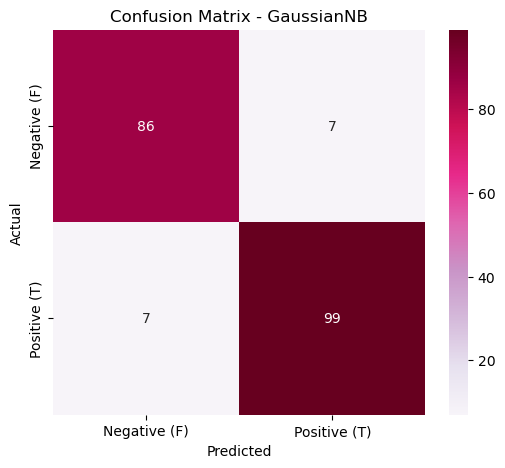

In [96]:
cm = confusion_matrix(y_test, y_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='PuRd')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - GaussianNB")

plt.xticks([0.5,1.5], ["Negative (F)", "Positive (T)"])
plt.yticks([0.5,1.5], ["Negative (F)", "Positive (T)"])

plt.show()

Explain why GaussianNB is appropriate for this dataset?

Gaussian Naive Bayes is appropriate because, The features (glucose, blood pressure) are continuous numeric variables, GaussianNB assumes features follow a normal (Gaussian) distribution, and it works well for small-to-medium medical datasets.

Since medical measurements like glucose often approximately follow a normal distribution, GaussianNB is suitable.

Which metric should a doctor prioritize in this scenario: Precision or Recall?

Recall measures.

It tells us that out of all actual diabetic patients, how many did model correctly detect?
Since False Negatives are dangerous, Recall must be maximized.

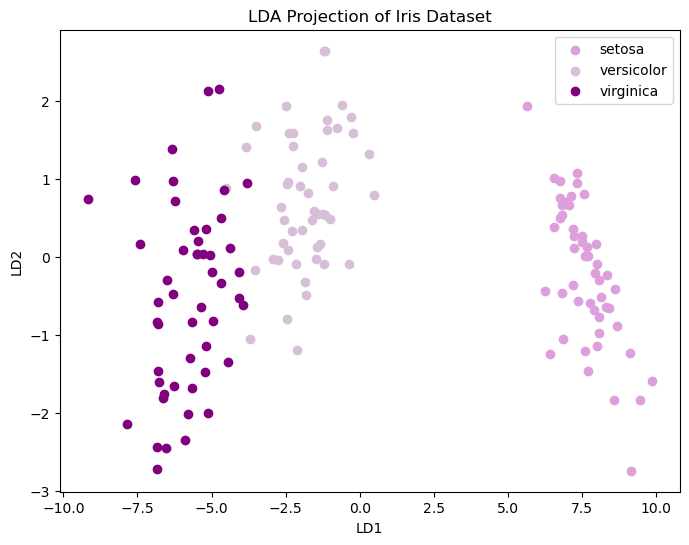

In [97]:
#Task 2
from sklearn.datasets import load_iris
iris = load_iris()

X = iris.data
y = iris.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_scaled, y)
colors = ['plum', 'thistle', 'purple']
plt.figure(figsize=(8,6))

for label in range(3):
    plt.scatter(
        X_lda[y == label, 0],
        X_lda[y == label, 1],
        color = colors[label],
        label=iris.target_names[label]
    )

plt.xlabel("LD1")
plt.ylabel("LD2")
plt.title("LDA Projection of Iris Dataset")
plt.legend()
plt.show()


Confusion Matrix:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


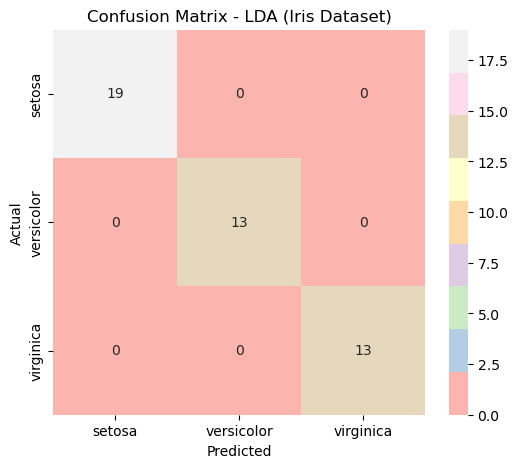

In [98]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

clf = LinearDiscriminantAnalysis()
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)


cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)


plt.figure(figsize=(6,5))
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Pastel1',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - LDA (Iris Dataset)")
plt.show()

In [99]:
#Task 3
from sklearn.metrics import accuracy_score, f1_score
df = pd.read_csv("Naive-Bayes-Classification-Data.csv")

X = df[['glucose', 'bloodpressure']]
y = df['diabetes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

y_preds = nb_model.predict(X_test_scaled)

gnb_pred = y_preds  

lda_model = LinearDiscriminantAnalysis()
lda_model.fit(X_train_scaled, y_train)
lda_pred = lda_model.predict(X_test_scaled)

results = {
    "Model": ["GaussianNB", "LDA"],
    "Accuracy": [
        accuracy_score(y_test, gnb_pred),
        accuracy_score(y_test, lda_pred)
    ],
    "Macro F1": [
        f1_score(y_test, gnb_pred, average='macro'),
        f1_score(y_test, lda_pred, average='macro')
    ],
    "Recall": [
        recall_score(y_test, gnb_pred),
        recall_score(y_test, lda_pred)
    ]
}

comparison_df = pd.DataFrame(results)
print(comparison_df)

        Model  Accuracy  Macro F1    Recall
0  GaussianNB  0.929648  0.929347  0.933962
1         LDA  0.929648  0.929504  0.915094


LDA assumes that classes share the same covariance matrix. If performance is slightly worse than Naive Bayes, it suggests that the covariance assumption may not be fully hold in diabetes dataset.

Which model would you deploy in a real clinic?

Will choose GaussianNB if priority is High recall. Because it may detect more diabetis patients and lower risk of sick patients.